In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
df = pd.read_csv('Day12_Used_Car_Preprocessing_Dataset (1).csv')
df.head()

,Car_ID,Brand,Year,Mileage_Km,Engine_CC,Power_BHP,Fuel_Type,Transmission,City,Seller_Type,Condition,Previous_Owners,Accidents_Reported,Service_Score,Resale_Price_Lakh
0,CAR0001,Skoda,2021,69708,1152,128.8,Diesel,Manual,Lucknow,Individual,Good,1,0,72,6.38
1,CAR0002,Toyota,2020,88881,903,146.5,Diesel,Automatic,Chandigarh,Individual,Good,1,0,87,4.83
2,CAR0003,Volkswagen,2021,43646,1446,185.9,Diesel,Automatic,Hyderabad,Individual,Very Good,2,0,90,7.30
3,CAR0004,Tata,2019,70847,2069,148.8,Petrol,Manual,Lucknow,Individual,Excellent,3,0,66,3.82
4,CAR0005,Tata,2016,101228,1657,206.0,Petrol,Automatic,Ahmedabad,Dealer,Very Good,2,0,84,1.93


### Getting information about the dataset

In [4]:
df.describe()
df.info()
df.columns
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Car_ID              320 non-null    object 
 1   Brand               320 non-null    object 
 2   Year                320 non-null    int64  
 3   Mileage_Km          320 non-null    int64  
 4   Engine_CC           320 non-null    int64  
 5   Power_BHP           320 non-null    float64
 6   Fuel_Type           320 non-null    object 
 7   Transmission        320 non-null    object 
 8   City                320 non-null    object 
 9   Seller_Type         320 non-null    object 
 10  Condition           320 non-null    object 
 11  Previous_Owners     320 non-null    int64  
 12  Accidents_Reported  320 non-null    int64  
 13  Service_Score       320 non-null    int64  
 14  Resale_Price_Lakh   320 non-null    float64
dtypes: float64(2), int64(6), object(7)
memory usage: 37.6+ KB

(320, 15)

### Checking the data

In [7]:
df.isnull().sum()

,0
Car_ID,0
Brand,0
Year,0
Mileage_Km,0
Engine_CC,0
Power_BHP,0
Fuel_Type,0
Transmission,0
City,0
Seller_Type,0


In [8]:
df.duplicated().sum()

np.int64(0)

### Checking the data type

In [9]:
df.dtypes

,0
Car_ID,object
Brand,object
Year,int64
Mileage_Km,int64
Engine_CC,int64
Power_BHP,float64
Fuel_Type,object
Transmission,object
City,object
Seller_Type,object


### Identifying data type of columns

In [11]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = df.select_dtypes(
    include=["object"]
).columns

print("Numerical Columns:", numerical_columns)
print("Categorical Columns:", categorical_columns)


Numerical Columns: Index(['Year', 'Mileage_Km', 'Engine_CC', 'Power_BHP', 'Previous_Owners',
       'Accidents_Reported', 'Service_Score', 'Resale_Price_Lakh'],
      dtype='object')
Categorical Columns: Index(['Car_ID', 'Brand', 'Fuel_Type', 'Transmission', 'City', 'Seller_Type',
       'Condition'],
      dtype='object')


Checking Outliers

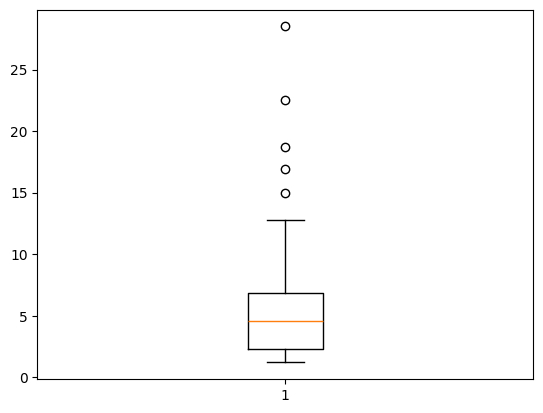

In [12]:
import matplotlib.pyplot as plt

plt.boxplot(df["Resale_Price_Lakh"])
plt.show()

In [14]:
# 1. Calculate Q1 and Q3
Q1 = df["Resale_Price_Lakh"].quantile(0.25)
Q3 = df["Resale_Price_Lakh"].quantile(0.75)

# 2. Calculate IQR
IQR = Q3 - Q1

# 3. Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Display the bounds
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# 5. Identify outliers
outliers = df[
    (df["Resale_Price_Lakh"] < lower_bound) |
    (df["Resale_Price_Lakh"] > upper_bound)
]

print("Number of outliers:", len(outliers))
print(outliers)

Q1: 2.2775
Q3: 6.835
IQR: 4.5575
Lower Bound: -4.55875
Upper Bound: 13.67125
Number of outliers: 5
      Car_ID       Brand  ...  Service_Score  Resale_Price_Lakh
31   CAR0032  Volkswagen  ...             94               15.0
149  CAR0150       Skoda  ...             69               22.5
188  CAR0189     Renault  ...             58               18.7
227  CAR0228     Hyundai  ...             78               28.5
261  CAR0262     Hyundai  ...             82               16.9

[5 rows x 15 columns]


### Removing the outliers

In [15]:
df = df[
    (df["Resale_Price_Lakh"] >= lower_bound) &
    (df["Resale_Price_Lakh"] <= upper_bound)
]

print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (315, 15)


### Checking if the outliers are removed

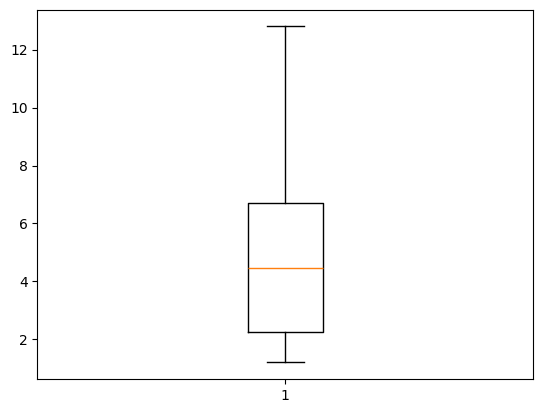

In [16]:
import matplotlib.pyplot as plt

plt.boxplot(df["Resale_Price_Lakh"])
plt.show()

### Separate Features (X) and Target (y)

In [17]:
X = df.drop("Resale_Price_Lakh", axis=1)
y = df["Resale_Price_Lakh"]

### Sperating data for training and testing

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Encoding

In [21]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown="ignore")

Data leakage

In [22]:
from sklearn.preprocessing import StandardScaler

# Select only numerical columns
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns

scaler = StandardScaler()

# Fit ONLY on training data
X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])

# Transform test data using the same scaler
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

Verification

In [23]:
X_train.shape

(252, 14)

In [24]:
X_test.shape

(63, 14)

In [25]:
X_train.isnull().sum()

,0
Car_ID,0
Brand,0
Year,0
Mileage_Km,0
Engine_CC,0
Power_BHP,0
Fuel_Type,0
Transmission,0
City,0
Seller_Type,0
